In [2]:
import sys
sys.path.insert(0, "/workspace/lerobot/src")

import numpy as np
import torch
import matplotlib.pyplot as plt

from lerobot.datasets.lerobot_dataset import LeRobotDataset
from lerobot.policies.smolvla.modeling_smolvla import SmolVLAPolicy
from lerobot.policies.factory import make_pre_post_processors

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("No GPU, using CPU")

GPU: NVIDIA GeForce RTX 5060 Ti


In [3]:
MODEL_ID = "NLTuan/smolvla_red_block_in_tape"

model = SmolVLAPolicy.from_pretrained(MODEL_ID)
model = model.to(device)
model.eval()

print(f"Camera inputs : {list(model.config.image_features.keys())}")
print(f"Action dim    : {model.config.action_feature.shape[0]}")
print(f"Chunk size    : {model.config.n_action_steps}")
print(f"Max state dim : {model.config.max_state_dim}")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading  HuggingFaceTB/SmolVLM2-500M-Video-Instruct weights ...
Reducing the number of VLM layers to 16 ...
Camera inputs : ['observation.images.camera1', 'observation.images.camera2', 'observation.images.camera3', 'observation.images.empty_camera_0']
Action dim    : 6
Chunk size    : 32
Max state dim : 32


In [5]:
preprocess, postprocess = make_pre_post_processors(
    model.config,
    MODEL_ID,
    preprocessor_overrides={"device_processor": {"device": str(device)}},
)
print("Preprocessors ready ✓")

Preprocessors ready ✓


In [6]:
DATASET_ID = "ThavT/red_block_in_tape"

dataset = LeRobotDataset(DATASET_ID)
print(f"{dataset.num_episodes} episodes, {len(dataset)} frames total")
print(f"FPS: {dataset.fps}")
print(f"\nFeatures: {list(dataset.features.keys())}")

33 episodes, 16914 frames total
FPS: 30

Features: ['action', 'observation.state', 'observation.images.cam_0', 'observation.images.cam_1', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index']


In [7]:
for ep in range(dataset.num_episodes):
    f = dataset.meta.episodes["dataset_from_index"][ep]
    t = dataset.meta.episodes["dataset_to_index"][ep]
    print(f"Episode {ep:3d}: frames {f}–{t}  ({t - f} steps, {(t - f) / dataset.fps:.1f}s)")

Episode   0: frames 0–504  (504 steps, 16.8s)
Episode   1: frames 504–1018  (514 steps, 17.1s)
Episode   2: frames 1018–1531  (513 steps, 17.1s)
Episode   3: frames 1531–2043  (512 steps, 17.1s)
Episode   4: frames 2043–2557  (514 steps, 17.1s)
Episode   5: frames 2557–3070  (513 steps, 17.1s)
Episode   6: frames 3070–3581  (511 steps, 17.0s)
Episode   7: frames 3581–4095  (514 steps, 17.1s)
Episode   8: frames 4095–4606  (511 steps, 17.0s)
Episode   9: frames 4606–5114  (508 steps, 16.9s)
Episode  10: frames 5114–5622  (508 steps, 16.9s)
Episode  11: frames 5622–6132  (510 steps, 17.0s)
Episode  12: frames 6132–6646  (514 steps, 17.1s)
Episode  13: frames 6646–7163  (517 steps, 17.2s)
Episode  14: frames 7163–7677  (514 steps, 17.1s)
Episode  15: frames 7677–8185  (508 steps, 16.9s)
Episode  16: frames 8185–8701  (516 steps, 17.2s)
Episode  17: frames 8701–9214  (513 steps, 17.1s)
Episode  18: frames 9214–9726  (512 steps, 17.1s)
Episode  19: frames 9726–10242  (516 steps, 17.2s)
Epis

In [21]:
EPISODE_IDX = 4

from_idx = dataset.meta.episodes["dataset_from_index"][EPISODE_IDX]
to_idx   = dataset.meta.episodes["dataset_to_index"][EPISODE_IDX]
ep_len   = to_idx - from_idx

frames = [dataset[i] for i in range(from_idx, to_idx)]
ground_truth = np.stack([f["action"].numpy() for f in frames])  # (T, action_dim)

print(f"Episode {EPISODE_IDX}: {ep_len} frames")
print(f"Ground-truth shape: {ground_truth.shape}")

Episode 4: 514 frames
Ground-truth shape: (514, 6)


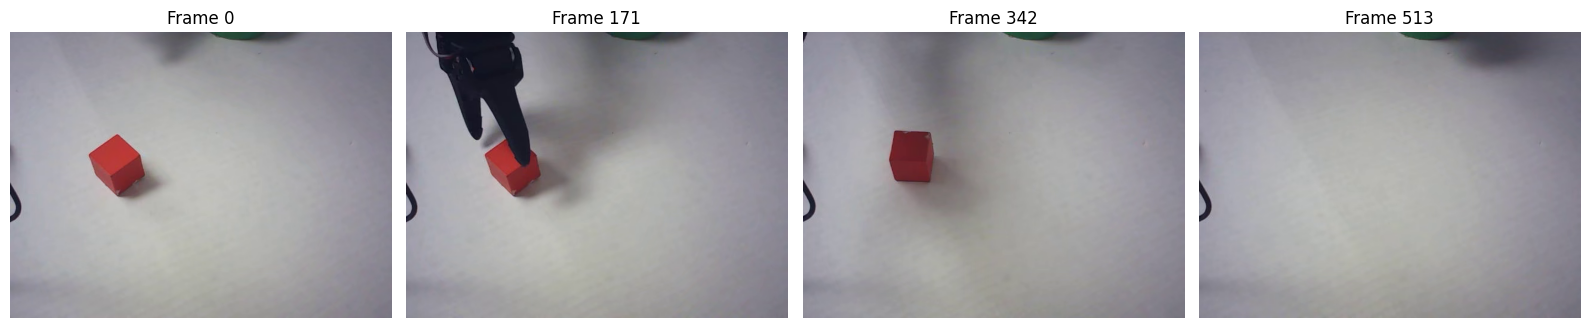

In [22]:
camera_key = [k for k in frames[0] if k.startswith("observation.images.")][0]
sample_indices = np.linspace(0, ep_len - 1, 4, dtype=int)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, idx in zip(axes, sample_indices):
    img = frames[idx][camera_key].permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(f"Frame {idx}")
    ax.axis("off")
plt.tight_layout()
plt.show()

# Predict 1 chunk

In [23]:
# The frame index *within* the episode to start the chunk from
START_STEP = 0  # ← change this to start at a different point in the episode

chunk_size = model.config.n_action_steps
print(f"Chunk size (n_action_steps): {chunk_size}")

# Make sure there's enough ground truth left to compare
assert START_STEP + chunk_size <= ep_len, (
    f"START_STEP={START_STEP} + chunk_size={chunk_size} exceeds episode length {ep_len}"
)

# Build batch from the single starting frame
frame = frames[START_STEP]
batch = {
    k: v.unsqueeze(0).to(device)
    for k, v in frame.items()
    if isinstance(v, torch.Tensor) and k.startswith("observation")
}
if "task" in frame:
    batch["task"] = [frame["task"]]

batch = preprocess(batch)

# Generate the full chunk in one forward pass
model.reset()
with torch.no_grad():
    action_chunk = model.predict_action_chunk(batch)   # (1, chunk_size, action_dim)

action_chunk = postprocess(action_chunk)
predicted_chunk = action_chunk[0].cpu().numpy()        # (chunk_size, action_dim)
gt_chunk = ground_truth[START_STEP : START_STEP + chunk_size]  # same slice

print(f"Predicted chunk shape : {predicted_chunk.shape}")
print(f"Ground-truth chunk shape : {gt_chunk.shape}")

Chunk size (n_action_steps): 32
Predicted chunk shape : (32, 6)
Ground-truth chunk shape : (32, 6)


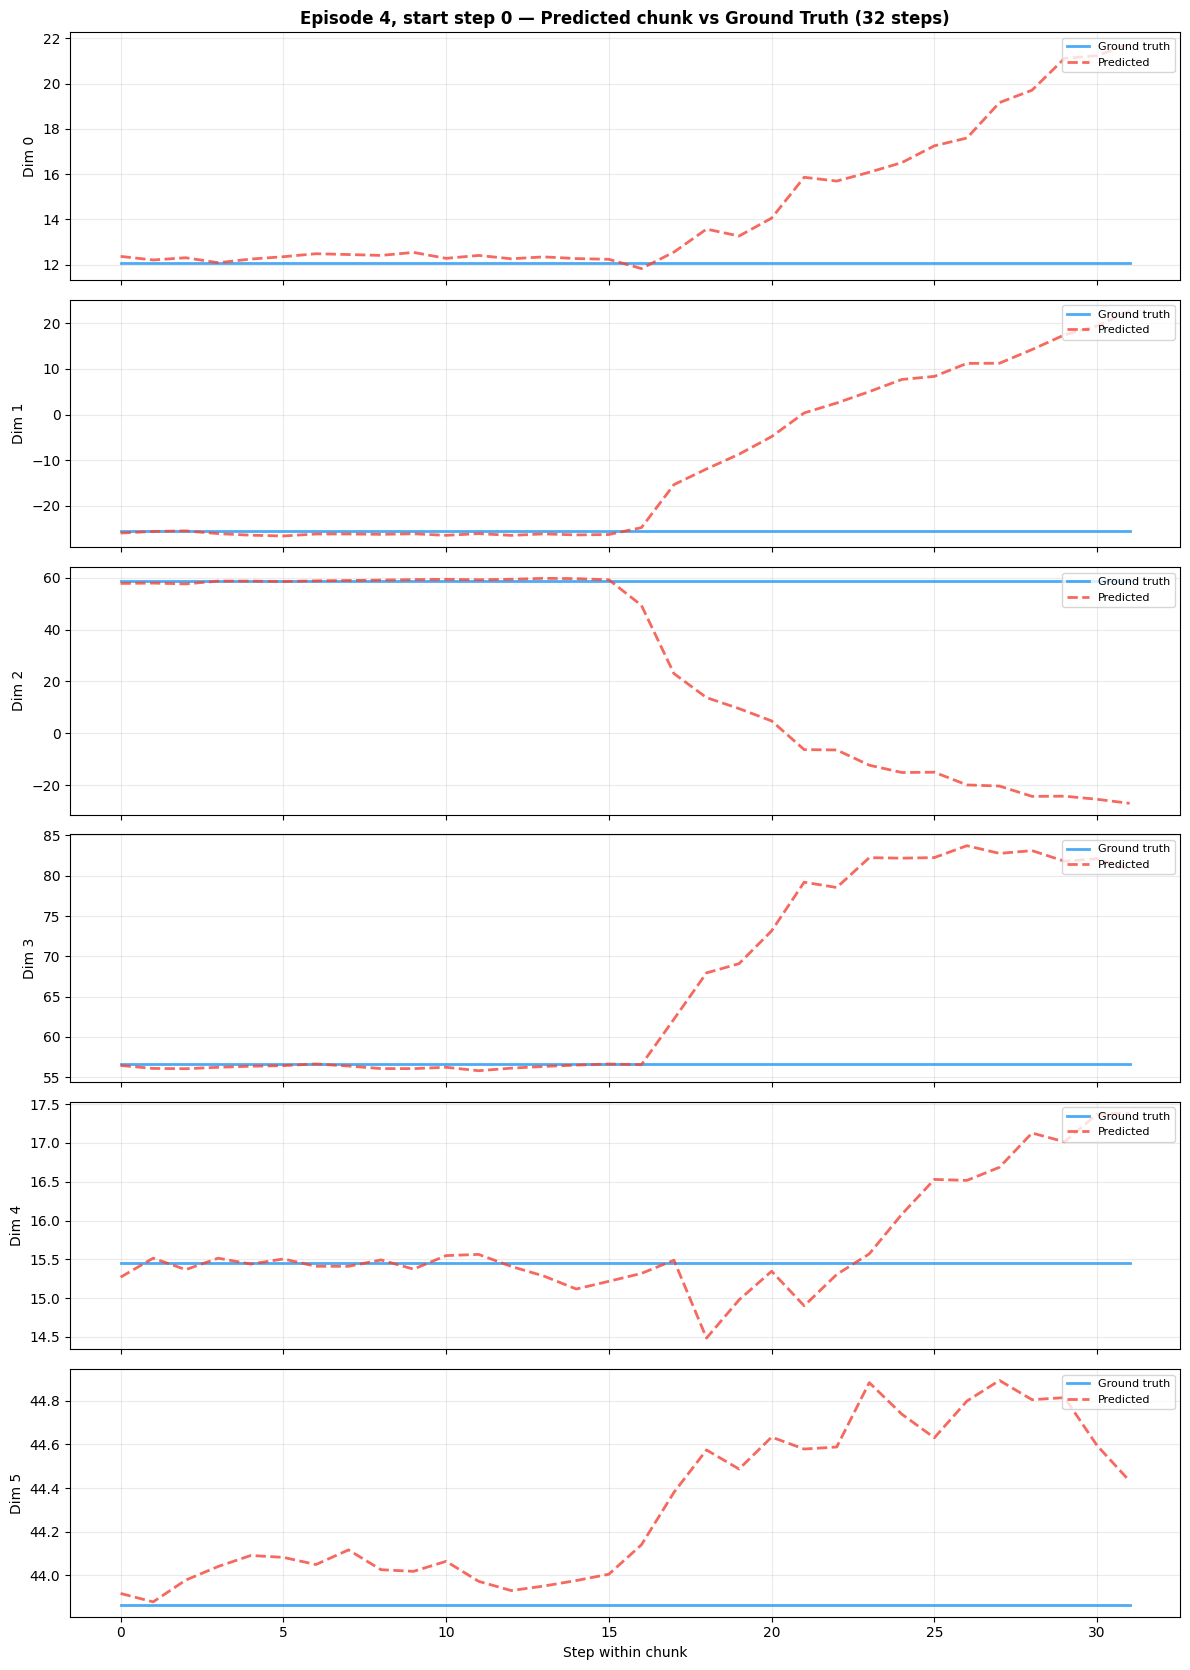

In [24]:
action_dim = predicted_chunk.shape[1]
dims_to_plot = min(action_dim, 8)
timesteps = np.arange(chunk_size)

fig, axes = plt.subplots(dims_to_plot, 1, figsize=(12, 2.8 * dims_to_plot), sharex=True)
if dims_to_plot == 1:
    axes = [axes]

for d in range(dims_to_plot):
    axes[d].plot(timesteps, gt_chunk[:, d],        label="Ground truth", color="#2196F3", linewidth=2, alpha=0.8)
    axes[d].plot(timesteps, predicted_chunk[:, d], label="Predicted",    color="#F44336", linewidth=2, alpha=0.8, linestyle="--")
    axes[d].set_ylabel(f"Dim {d}", fontsize=10)
    axes[d].grid(True, alpha=0.25)
    axes[d].legend(loc="upper right", fontsize=8)

axes[0].set_title(
    f"Episode {EPISODE_IDX}, start step {START_STEP} — "
    f"Predicted chunk vs Ground Truth ({chunk_size} steps)",
    fontsize=12, fontweight="bold"
)
axes[-1].set_xlabel("Step within chunk")
plt.tight_layout()
plt.show()

Chunk MSE : 3.622758   RMSE : 1.903354   MAE : 1.163974

  Dim  0  MSE=1.977426  MAE=0.996755
  Dim  1  MSE=1.658825  MAE=1.112751
  Dim  2  MSE=11.137244  MAE=1.882422
  Dim  3  MSE=6.839192  MAE=2.566700
  Dim  4  MSE=0.054136  MAE=0.202492
  Dim  5  MSE=0.069723  MAE=0.222727


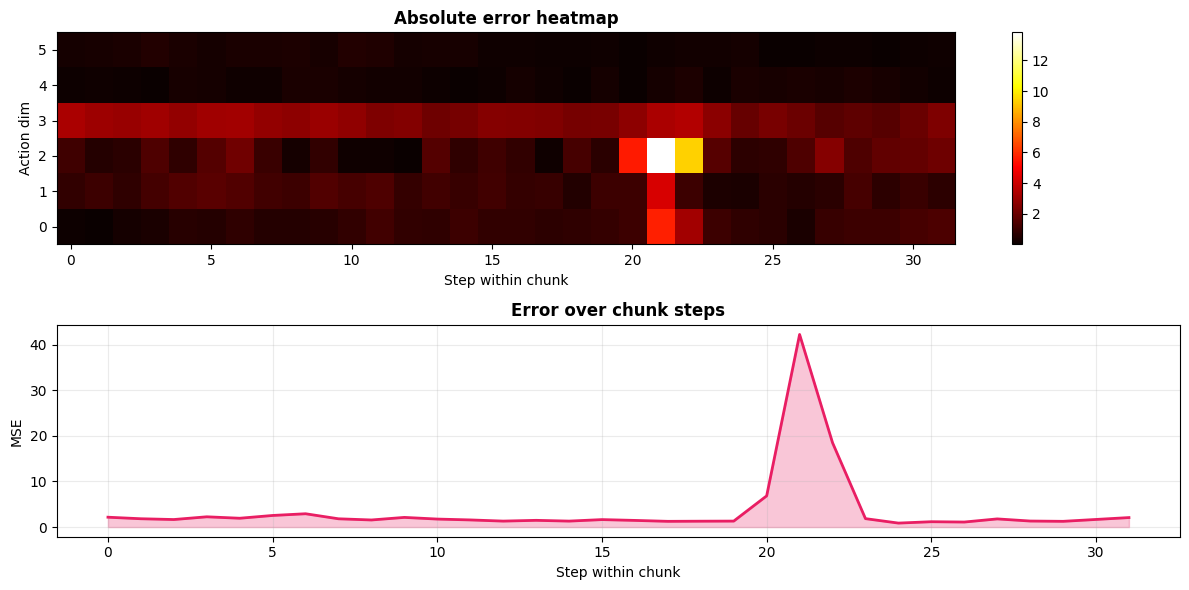

In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse  = mean_squared_error(gt_chunk, predicted_chunk)
mae  = mean_absolute_error(gt_chunk, predicted_chunk)

mse_per_dim  = np.mean((gt_chunk - predicted_chunk) ** 2, axis=0)
mae_per_dim  = np.mean(np.abs(gt_chunk - predicted_chunk), axis=0)
mse_per_step = np.mean((gt_chunk - predicted_chunk) ** 2, axis=1)

print(f"Chunk MSE : {mse:.6f}   RMSE : {np.sqrt(mse):.6f}   MAE : {mae:.6f}\n")
for d in range(action_dim):
    print(f"  Dim {d:2d}  MSE={mse_per_dim[d]:.6f}  MAE={mae_per_dim[d]:.6f}")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

im = ax1.imshow(np.abs(gt_chunk - predicted_chunk).T, aspect="auto", cmap="hot", origin="lower")
ax1.set_xlabel("Step within chunk"); ax1.set_ylabel("Action dim")
ax1.set_title("Absolute error heatmap", fontweight="bold")
plt.colorbar(im, ax=ax1)

ax2.plot(np.arange(chunk_size), mse_per_step, color="#E91E63", linewidth=2)
ax2.fill_between(np.arange(chunk_size), 0, mse_per_step, alpha=0.25, color="#E91E63")
ax2.set_xlabel("Step within chunk"); ax2.set_ylabel("MSE")
ax2.set_title("Error over chunk steps", fontweight="bold")
ax2.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

# Predicting full chunks chained after one another

In [25]:
model.reset()
chunk_size = model.config.n_action_steps
print(f"Chunk size: {chunk_size}")
print(f"Episode length: {ep_len}")
print(f"Number of model calls: {int(np.ceil(ep_len / chunk_size))}\n")

all_predicted_chunks = []

for step in range(0, ep_len, chunk_size):
    frame = frames[step]

    batch = {
        k: v.unsqueeze(0).to(device)
        for k, v in frame.items()
        if isinstance(v, torch.Tensor) and k.startswith("observation")
    }
    if "task" in frame:
        batch["task"] = [frame["task"]]

    batch = preprocess(batch)

    with torch.no_grad():
        action_chunk = model.predict_action_chunk(batch)  # (1, chunk_size, action_dim)

    action_chunk = postprocess(action_chunk)
    predicted = action_chunk[0].cpu().numpy()  # (chunk_size, action_dim)

    # The last chunk may go beyond the episode — trim it
    remaining = ep_len - step
    all_predicted_chunks.append(predicted[:remaining])

    print(f"  Step {step:4d}: predicted steps {step}–{min(step + chunk_size, ep_len) - 1}")

predictions_full = np.concatenate(all_predicted_chunks, axis=0)  # (ep_len, action_dim)
print(f"\nFull predicted trajectory shape : {predictions_full.shape}")
print(f"Ground truth shape              : {ground_truth.shape}")

Chunk size: 32
Episode length: 514
Number of model calls: 17

  Step    0: predicted steps 0–31
  Step   32: predicted steps 32–63
  Step   64: predicted steps 64–95
  Step   96: predicted steps 96–127
  Step  128: predicted steps 128–159
  Step  160: predicted steps 160–191
  Step  192: predicted steps 192–223
  Step  224: predicted steps 224–255
  Step  256: predicted steps 256–287
  Step  288: predicted steps 288–319
  Step  320: predicted steps 320–351
  Step  352: predicted steps 352–383
  Step  384: predicted steps 384–415
  Step  416: predicted steps 416–447
  Step  448: predicted steps 448–479
  Step  480: predicted steps 480–511
  Step  512: predicted steps 512–513

Full predicted trajectory shape : (514, 6)
Ground truth shape              : (514, 6)


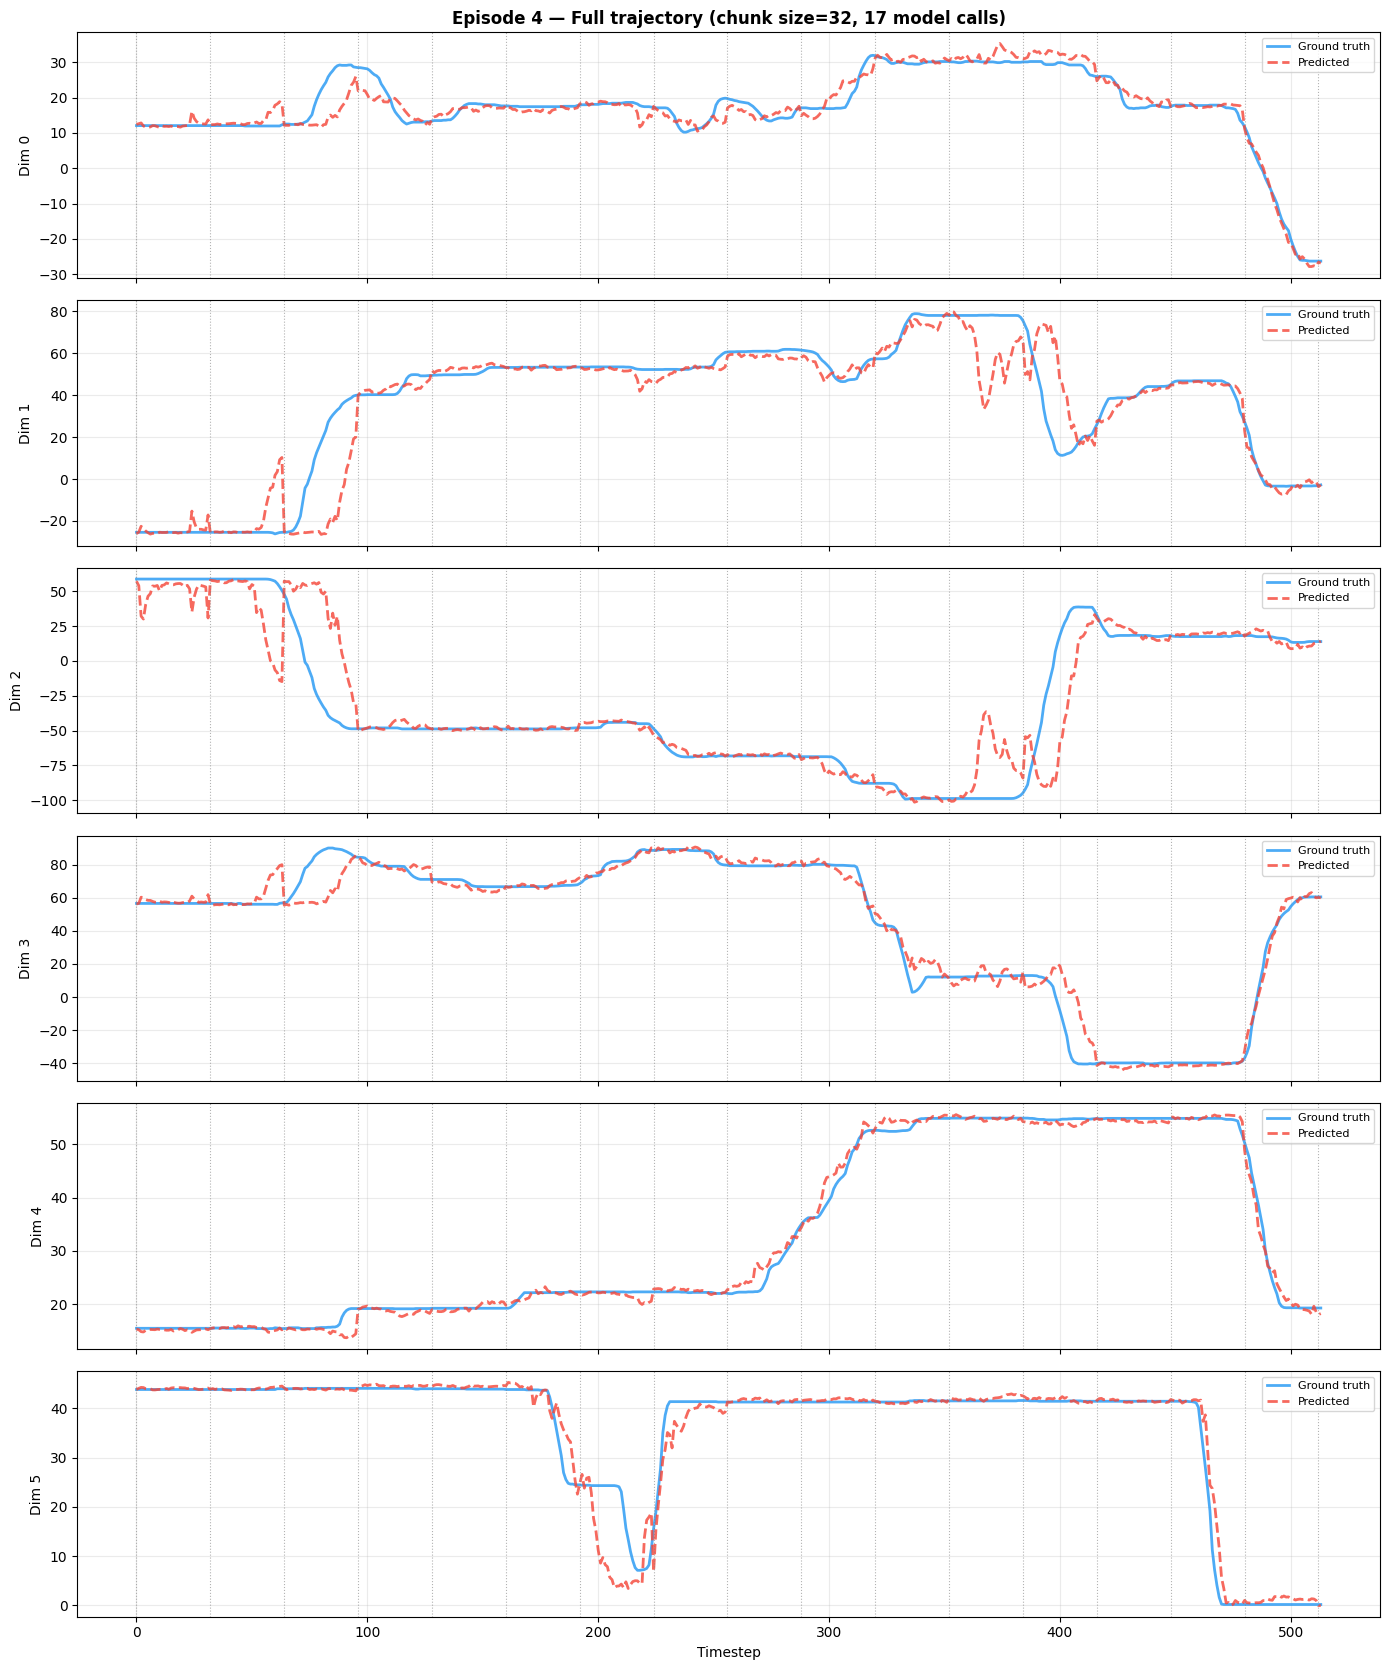

In [26]:
action_dim = predictions_full.shape[1]
dims_to_plot = min(action_dim, 8)
timesteps = np.arange(ep_len)

# Draw a vertical line at each chunk boundary so you can see where re-predictions happen
chunk_boundaries = list(range(0, ep_len, chunk_size))

fig, axes = plt.subplots(dims_to_plot, 1, figsize=(14, 2.8 * dims_to_plot), sharex=True)
if dims_to_plot == 1:
    axes = [axes]

for d in range(dims_to_plot):
    axes[d].plot(timesteps, ground_truth[:, d],       label="Ground truth", color="#2196F3", linewidth=2, alpha=0.8)
    axes[d].plot(timesteps, predictions_full[:, d],   label="Predicted",    color="#F44336", linewidth=2, alpha=0.8, linestyle="--")
    for b in chunk_boundaries:
        axes[d].axvline(x=b, color="gray", linewidth=0.8, linestyle=":", alpha=0.6)
    axes[d].set_ylabel(f"Dim {d}", fontsize=10)
    axes[d].grid(True, alpha=0.25)
    axes[d].legend(loc="upper right", fontsize=8)

axes[0].set_title(
    f"Episode {EPISODE_IDX} — Full trajectory (chunk size={chunk_size}, "
    f"{len(chunk_boundaries)} model calls)",
    fontsize=12, fontweight="bold"
)
axes[-1].set_xlabel("Timestep")
plt.tight_layout()
plt.show()